# 03 – Data Preparation

**Project:** Diabetes Prediction ML  
**Seminar:** Advanced Applied Data Science – Goethe University Frankfurt  
**Dataset:** CDC BRFSS 2015 – Diabetes Health Indicators (UCI #891)  
**Target:** `Diabetes_binary` (0 = No Diabetes, 1 = Prediabetes/Diabetes)  
**CRISP-DM phase:** 3 – Data Preparation · Train/Test Split & Formatting

---

## Purpose of this notebook
With the data examined and its quality characterised (NB02), this notebook turns the raw dataset into the clean, reproducible train/test artifact that every subsequent notebook builds on. Its single most important step is the **train/test split**, performed *before* any feature transformation so that no information from the test set can leak into the fitted pipeline. The split is both **group-aware** and **stratified**: rows sharing an identical 21-feature profile are kept entirely on one side of the split — removing the duplicate- and conflict-leakage diagnosed in NB02 — while stratification preserves the ~86/14 class imbalance equally in train and test. No features are engineered here — this notebook covers only the split, the feature-type definitions, and the persisted raw train/test sets (`data/processed/`). All transformations and constructed features follow in NB05.

## 1. Setup

All libraries are imported centrally here. The global seed is set once and used consistently across every randomised step (split, SMOTE, models) — so the entire notebook is reproducible from a single value.

In [1]:
# install required packages if missing
import importlib.util, subprocess, sys
if importlib.util.find_spec('ucimlrepo') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ucimlrepo'])

# silence only FutureWarnings, keep all other warnings visible
import warnings
warnings.simplefilter("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import StratifiedGroupKFold  # group-aware + stratified split

# deterministic plotting style (consistent with NB02)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

SEED = 42  # global seed, reused in every randomised step

# Anchor all paths to the project root so they don't depend on the kernel's
# working directory. PROJECT_ROOT = the first parent folder that contains
# 'notebooks/' → always resolves to the repo, never to Downloads.
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "notebooks").is_dir())
DATA_DIR   = PROJECT_ROOT / "data" / "processed"          # train/test parquets + feature_meta.json
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "nb03"            # figures saved here
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the dataset

The dataset is loaded again directly from the UCI ML Repository (ID 891). This keeps the notebook runnable independently of any cached state from Notebook 02 and ensures it always operates on the original version.

In [2]:
# load the dataset fresh from the UCI repo (independent of NB02's cached state)
dataset = fetch_ucirepo(id=891)
X = dataset.data.features.copy()
y = dataset.data.targets.squeeze().copy()  # squeeze: single-column DataFrame -> Series

print(f"Features: {X.shape}")
print(f"Target:   {y.shape}")
print(f"Classes:  {y.value_counts().to_dict()}")
print(f"Prevalence: {y.mean():.4f}")  # share of positive class (~0.1393)

Features: (253680, 21)
Target:   (253680,)
Classes:  {0: 218334, 1: 35346}
Prevalence: 0.1393


## 3. Group-aware Train/Test Split

The split is performed as the very first step, before any further transformation — this is mandatory to prevent data leakage: every subsequent step (scaling, encoding, feature construction in NB05) is fitted exclusively on the training fold.

**Why group-aware?**
NB02 showed that the dataset contains 14.0% exact duplicates plus colliding profiles (identical 21-feature vector but different label). A naive random split would scatter such identical profiles across both sides — the same profile would then sit in both training *and* test. The model would effectively have seen the answer during training, and the test metric would be inflated.

We therefore group on the **21-feature profile**: all rows sharing an identical feature vector form one group and land entirely on *one* side of the split. This eliminates both duplicate and conflict leakage in a single step. We group on the 21 features (not on all 22 columns including the label), because the model only sees the features — splitting by label would tear colliding profiles apart again.

**Why also stratified?**
With a class distribution of roughly 86 / 14, stratification keeps the prevalence of the positive class approximately equal in train and test. `StratifiedGroupKFold` combines both objectives: group-pure (guaranteed) and class-balanced (approximate, since whole groups move together). We take the first of the five folds as the 80/20 holdout.

**Why an 80/20 ratio?**
There is no theoretically fixed split ratio — what matters is the *absolute* size of each set, not the proportion itself (Guyon, 1997; Afendras & Markatou, 2019). Two effects pull against each other: a larger training share gives the model more data, which improves generalisation and lowers the risk of overfitting, while a larger test share yields a lower-variance performance estimate. Which ratio is best therefore depends on n. With ~253k rows both demands are satisfied at 80/20: the model trains on ~203k samples — overfitting is naturally suppressed by the sheer data volume — and the 20% holdout still holds ~50k samples (~7k positives at 14% prevalence), more than enough for a low-variance PR-AUC estimate. On a *small* dataset the same ratio would be problematic (overfitting risk is high regardless of the split, and a 20% test set becomes too small to estimate reliably) — which is why k-fold cross-validation is preferred there. An 80/20 split is thus specifically appropriate for a large dataset like this one; 75/25 (`n_splits=4`) would shrink the training set without measurably improving the estimate.



Unique profiles (groups): 227,908 of 253,680 rows
Profile overlap train/test:       0  (must be 0)

Train: 202,943 samples (80.0%)
Test:   50,737 samples (20.0%)

Prevalence of positive class (stratification keeps these ~equal):
  Overall: 0.1393
  Train:   0.1393
  Test:    0.1393


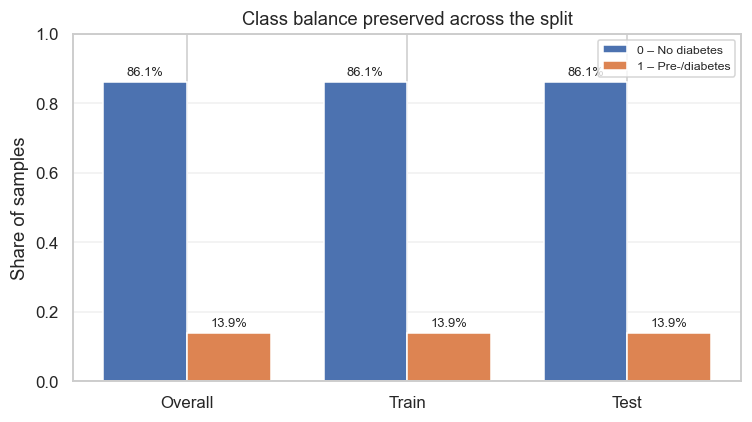

In [3]:
# Group ID per row = its full 21-feature profile.
# Rows with an identical feature vector get the same ID -> they form one group.
groups = X.groupby(list(X.columns)).ngroup()

# StratifiedGroupKFold honours `groups`: a whole group lands entirely in train OR test.
# n_splits=5 -> each fold ~20%; we take the first fold as the 80/20 holdout.
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(sgkf.split(X, y, groups))  # positional row indices

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# --- leakage check: no profile may appear on both sides ---
overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
assert not overlap, f"{len(overlap)} profiles leak across the split boundary!"

# --- stratification check: prevalence must stay within 0.5 pp of the overall rate ---
assert abs(y_train.mean() - y.mean()) < 0.005, "train prevalence drifted"
assert abs(y_test.mean()  - y.mean()) < 0.005, "test prevalence drifted"

# --- sanity output ---
print(f"Unique profiles (groups): {groups.nunique():>7,} of {len(X):,} rows")
print(f"Profile overlap train/test: {len(overlap):>7}  (must be 0)")
print()
print(f"Train: {X_train.shape[0]:>7,} samples ({len(train_idx)/len(X):.1%})")
print(f"Test:  {X_test.shape[0]:>7,} samples ({len(test_idx)/len(X):.1%})")  # not exactly 20%: groups can't be cut
print()
print("Prevalence of positive class (stratification keeps these ~equal):")
print(f"  Overall: {y.mean():.4f}")
print(f"  Train:   {y_train.mean():.4f}")
print(f"  Test:    {y_test.mean():.4f}")

# --- visual: class balance across Overall / Train / Test ---
splits  = {"Overall": y, "Train": y_train, "Test": y_test}
labels  = list(splits.keys())
share_0 = [(s == 0).mean() for s in splits.values()]
share_1 = [(s == 1).mean() for s in splits.values()]

idx, w = list(range(len(labels))), 0.38
fig, ax = plt.subplots(figsize=(7, 4))
b0 = ax.bar([i - w/2 for i in idx], share_0, w, label="0 – No diabetes",   color="#4C72B0", edgecolor="white")
b1 = ax.bar([i + w/2 for i in idx], share_1, w, label="1 – Pre-/diabetes", color="#DD8452", edgecolor="white")

for bars in (b0, b1):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(idx); ax.set_xticklabels(labels)
ax.set_ylabel("Share of samples"); ax.set_ylim(0, 1)
ax.set_title("Class balance preserved across the split", fontsize=12)
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()

# save before show() so the canvas isn't already cleared
fig.savefig(OUTPUT_DIR / "01_split_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Define feature types

The features are grouped by their semantic meaning. Although all variables are technically stored as integers, they differ substantially in content: some are binary indicators, others are ordinally encoded categories, two variables count the number of health-impaired days, and BMI is the only continuously interpretable numeric feature.

This grouping matters because different model types respond differently to feature scaling, outliers, and encoded categories. For a first baseline the features are kept as close to their original form as possible. This creates an unchanged reference point against which later feature-engineering variants can be compared.

The possible transformations identified in Notebook 02 — in particular BMI capping, hurdle encoding for MentHlth and PhysHlth, and composite features — are therefore not adopted as final decisions here, but constructed and tested systematically in the following notebooks. Whether a transformation is kept is decided empirically by cross-validation performance, not by the exploratory analysis alone.

In [4]:
# group features by semantic type — all stored as int, but they mean different things

BINARY_COLS = [                 # 0/1 yes-no indicators
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
]

ORDINAL_COLS = [                # ordered categories (GenHlth 1–5, Age/Education/Income brackets)
    "GenHlth",
    "Age",
    "Education",
    "Income",
]

COUNT_COLS = [                  # number of impaired days (0–30), strongly zero-inflated
    "MentHlth",
    "PhysHlth",
]

NUMERIC_COLS = [                # the only continuous feature
    "BMI",
]

ALL_FEATURES = BINARY_COLS + ORDINAL_COLS + COUNT_COLS + NUMERIC_COLS

# sanity check: every column accounted for exactly once (expect 21 == 21)
print(f"Number of defined features: {len(ALL_FEATURES)}")
print(f"Number of features in dataset: {X_train.shape[1]}")

print("\nColumns not defined:")            # dataset columns we forgot to list -> must be empty
print(set(X_train.columns) - set(ALL_FEATURES))

print("\nDefined but not in dataset:")     # names we listed that don't exist -> must be empty
print(set(ALL_FEATURES) - set(X_train.columns))

Number of defined features: 21
Number of features in dataset: 21

Columns not defined:
set()

Defined but not in dataset:
set()


## 5. Save split & metadata

`X_train`, `X_test`, `y_train` and `y_test` are persisted in **raw form** (the unchanged 21 features) to `data/processed/`, so the following notebooks can build on them directly without re-running the split. The feature-type lists are saved as JSON, so that pipeline construction in the following notebooks can reuse the column groupings without redundancy.

All transformations (BMI capping, categorisation, hurdle encoding) and constructed features follow in the next notebook — they are applied within training-only pipelines, with any learnable steps (e.g. scalers) fitted exclusively on the training fold to avoid leakage.

In [5]:
import json  # Path is already imported in the setup cell

# DATA_DIR comes from the setup cell (anchored to the repo, see PROJECT_ROOT)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# split data — raw 21 features; index kept so original rows stay traceable
X_train.to_parquet(DATA_DIR / "X_train.parquet", index=True)
X_test.to_parquet(DATA_DIR / "X_test.parquet", index=True)
y_train.to_frame().to_parquet(DATA_DIR / "y_train.parquet", index=True)
y_test.to_frame().to_parquet(DATA_DIR / "y_test.parquet", index=True)

# feature-type metadata — single source of truth, reused by NB04+ to build pipelines
feature_meta = {
    "binary_cols":  BINARY_COLS,
    "ordinal_cols": ORDINAL_COLS,
    "count_cols":   COUNT_COLS,
    "numeric_cols": NUMERIC_COLS,
    "all_features": ALL_FEATURES,
    "seed":         SEED,
}
with open(DATA_DIR / "feature_meta.json", "w") as f:
    json.dump(feature_meta, f, indent=2)

print("Saved to", DATA_DIR.resolve())
print(f"  X_train.parquet   — {X_train.shape}")
print(f"  X_test.parquet    — {X_test.shape}")
print(f"  y_train.parquet   — {y_train.shape}")
print(f"  y_test.parquet    — {y_test.shape}")
print(f"  feature_meta.json — {len(feature_meta)} entries")

Saved to C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\data\processed
  X_train.parquet   — (202943, 21)
  X_test.parquet    — (50737, 21)
  y_train.parquet   — (202943,)
  y_test.parquet    — (50737,)
  feature_meta.json — 6 entries


## References

- Afendras, G., & Markatou, M. (2019). Optimality of training/test size and resampling effectiveness in cross-validation. *Journal of Statistical Planning and Inference, 199*, 286–301. https://doi.org/10.1016/j.jspi.2018.07.005
- Guyon, I. (1997). *A scaling law for the validation-set training-set size ratio* [Technical report]. AT&T Bell Laboratories.
- UCI Machine Learning Repository. *CDC Diabetes Health Indicators* (Dataset #891). Original curation by A. Teboul (Kaggle). https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators